The user enters the chemical properties of a wine sample (such as alcohol, pH, acidity, etc.) into the system through a GUI.

The model processes these inputs and predicts the quality score of the wine.

The system then displays the output as:

Predicted Quality Score (0–10)

Optional: Quality Category (Low / Medium / High)

dataset link: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [5]:
# ==============================
# 1. Load Data
# ==============================
df = pd.read_csv("/content/winequality-red.csv")

# Remove duplicates
df = df.drop_duplicates()

In [6]:
# ==============================
# 2. Prepare Data
# ==============================
X = df.drop(columns=["quality"])
y = df["quality"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
# ==============================
# 3. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [8]:
# ==============================
# 4. Regression Function (MAIN PART)
# ==============================

def run_regression_model(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\nModel:", model.__class__.__name__)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score (Accuracy):", r2)

    return model, r2

In [9]:
# model1 = LinearRegression()
model2 = RandomForestRegressor(
    n_estimators=800,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
) # best

model3 = GradientBoostingRegressor(
    n_estimators=1000,     # more trees
    learning_rate=0.01,    # slower learning = better generalization
    max_depth=3,           # controlled complexity
    random_state=42
)

model4 = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# here model2 is selected as it has higher accuracy
trained_model, accuracy = run_regression_model(
    model2, X_train, X_test, y_train, y_test
)


Model: RandomForestRegressor
MSE : 0.3797730902086867
RMSE: 0.6162573246694003
R2 Score (Accuracy): 0.46386680584655715


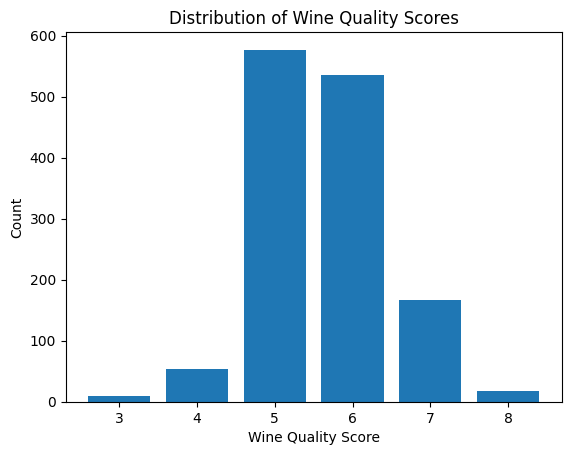

In [10]:
# Count values
quality_counts = df["quality"].value_counts().sort_index()

plt.figure()
plt.bar(quality_counts.index, quality_counts.values)

plt.xlabel("Wine Quality Score")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality Scores")

plt.show()